# Gemini Rescorla-Wagner Visualisations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/iowa_models/gemini/gemini_rw_results.csv")

### Variant Values

- Variant 1: Playing 100 trials, goal is to maximise profit

- Variant 2: Play until told to stop, goal is to maximise profit

- Variant 3: Play until told to stop, goal is to try to finish with at least 2500$

## Alpha Distribution by Variant (Learning Rate)

### Individual Historgrams 

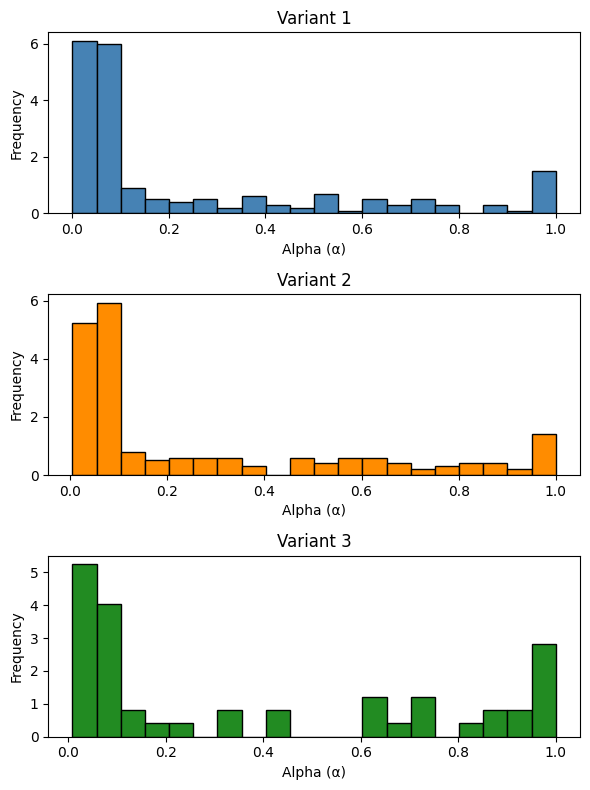

In [3]:
variants = sorted(df["variant"].unique())

fig, axes = plt.subplots(len(variants), 1, figsize=(6,8))

colors = ["steelblue", "darkorange", "forestgreen"]

for ax, v, c in zip(axes, variants, colors):
    subset = df[df["variant"] == v]
    ax.hist(subset["alpha"], bins=20, density=True, color=c, edgecolor="black") # density used to normalise
    ax.set_title(f"Variant {v}")
    ax.set_xlabel("Alpha (α)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Density Curves

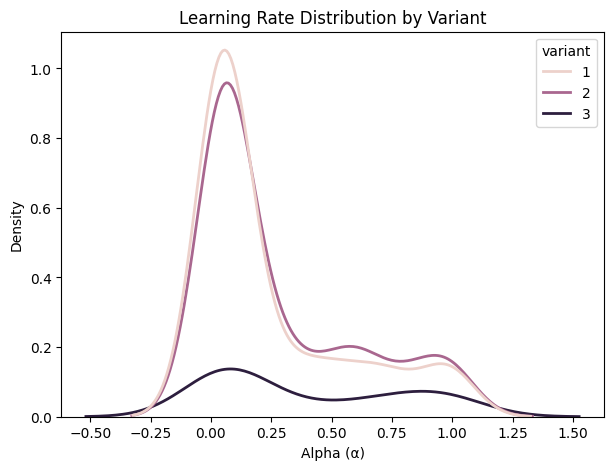

In [4]:
plt.figure(figsize=(7,5))

sns.kdeplot(data=df, x="alpha", hue="variant", linewidth=2)

plt.title("Learning Rate Distribution by Variant")
plt.xlabel("Alpha (α)")
plt.ylabel("Density")
plt.show()

**Variant 1:**
- large portion of the sessions show slow learning (α between 0 and 0.1)
- very small numbers of sessions show moderate learning (α between 0.1 and 0.7)
- small peak of sessions showing very reactive and fast learning (α between 0.7 and 1.0)

**Variant 2:**
- large portion of the sessions show slow learning (α between 0 and 0.1)
- small numbers of sessions show moderate learning (α between 0.1 and 0.7)
- very small peak of sessions showing very reactive and fast learning (α between 0.7 and 1.0)

**Variant 3:**
- large portion of the sessions show slow learning (α between 0 and 0.1)
- small numbers of sessions show moderate learning (α between 0.1 and 0.7)
- very small peak of sessions showing very reactive and fast learning (α between 0.7 and 1.0)

## Beta Distribution (Choice Consistency)

### Individual Histogram

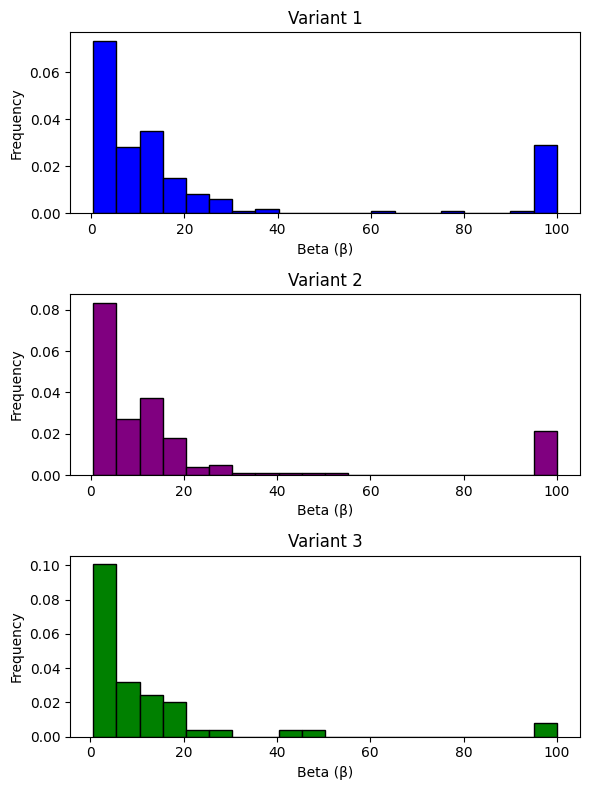

In [5]:
fig, axes = plt.subplots(len(variants), 1, figsize=(6,8))

colors = ["blue", "purple", "green"]

for ax, v, c in zip(axes, variants, colors):
    subset = df[df["variant"] == v]
    ax.hist(subset["beta"], bins=20, color=c, density=True, edgecolor="black")
    ax.set_title(f"Variant {v}")
    ax.set_xlabel("Beta (β)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Density Curves

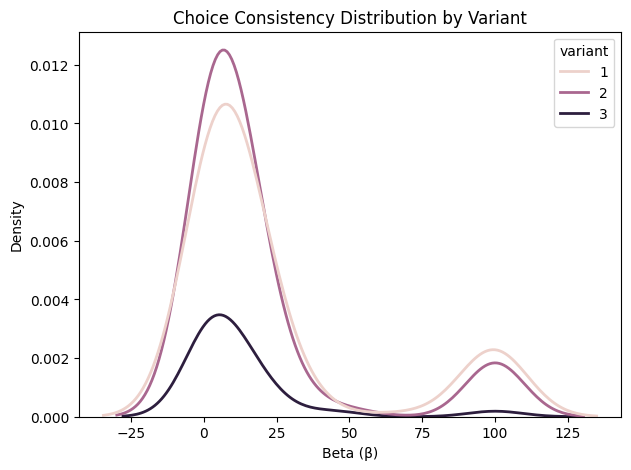

In [6]:
plt.figure(figsize=(7,5))

sns.kdeplot(data=df, x="beta", hue="variant", linewidth=2)

plt.title("Choice Consistency Distribution by Variant")
plt.xlabel("Beta (β)")
plt.ylabel("Density")
plt.show()

**Variant 1:**
- majority of the sessions show exploratory or noisy behaviour (β between 0 and 10)
- small amount of sessions show fairly consistent choices (β between 10 and 40)
- peak shows sessions that are highly deterministic, i.e. sticking to best deck (β between 40 and 100
)

**Variant 2:**
- majority of the sessions show exploratory or noisy behaviour (β between 0 and 10)
- small amount of sessions show fairly consistent choices (β between 10 and 40)
- peak shows sessions that are highly deterministic, i.e. sticking to best deck (β between 40 and 100
)

**Variant 3:**
- majority of the sessions show exploratory or noisy behaviour (β between 0 and 10)
- small amount of sessions show fairly consistent choices (β between 10 and 40)
- peak shows sessions that are highly deterministic, i.e. sticking to best deck (β between 40 and 100
)

## Boxplots Comparing Variants

<Figure size 640x480 with 0 Axes>

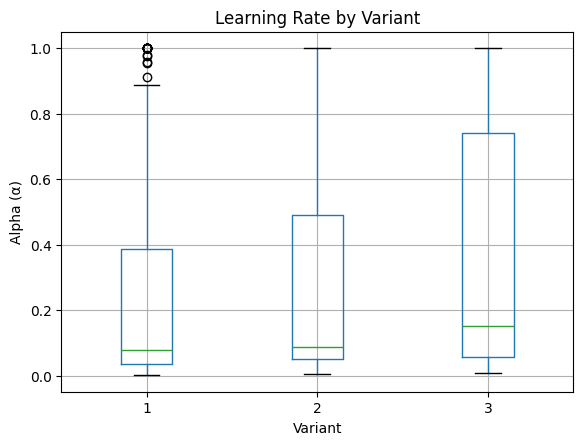

In [7]:
plt.figure()
df.boxplot(column="alpha", by="variant")
plt.title("Learning Rate by Variant")
plt.suptitle("")
plt.xlabel("Variant")
plt.ylabel("Alpha (α)")
plt.show()

<Figure size 640x480 with 0 Axes>

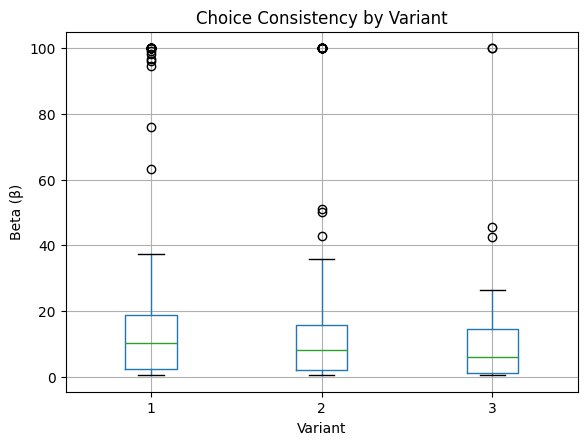

In [8]:
plt.figure()
df.boxplot(column="beta", by="variant")
plt.title("Choice Consistency by Variant")
plt.suptitle("")
plt.xlabel("Variant")
plt.ylabel("Beta (β)")
plt.show()

## Alpha vs Beta Scatter Plot

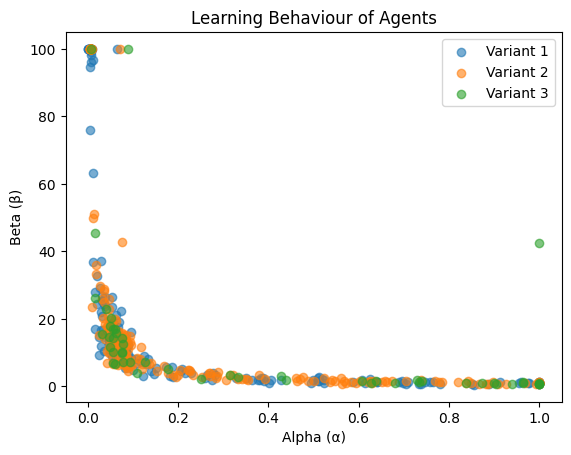

In [9]:
plt.figure()

for v in sorted(df["variant"].unique()):
    subset = df[df["variant"] == v]
    plt.scatter(subset["alpha"], subset["beta"], alpha=0.6, label=f"Variant {v}")

plt.xlabel("Alpha (α)")
plt.ylabel("Beta (β)")
plt.title("Learning Behaviour of Agents")
plt.legend()
plt.show()

## NLL Comparison (Model Fit)

<Figure size 640x480 with 0 Axes>

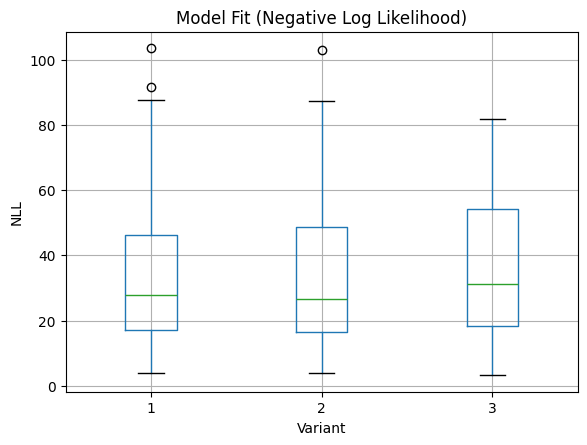

In [10]:
plt.figure()
df.boxplot(column="nll", by="variant")
plt.title("Model Fit (Negative Log Likelihood)")
plt.suptitle("")
plt.xlabel("Variant")
plt.ylabel("NLL")
plt.show()